### Analysis of Shovel or "Palas"
##### Files needed to run the jupyter notebook:
- `data/OriginalDatosdispatch.csv`
- `data/OriginalDatosContingenciaPala.csv`

In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [41]:
sns.set_theme(style='darkgrid')
custom_palette = ['#007B92', '#62CFC9', '#DC1F33', '#EFAC1E']
sns.set_palette(custom_palette)

In [42]:
TRUCK_ACTIVITY_PATH = 'data/OriginalDatosDispatch.csv'
df_trucks = pd.read_csv(TRUCK_ACTIVITY_PATH, encoding='utf-8', sep=';', decimal=',')

In [43]:
trailing_spaces = 5
max_length = max(map(lambda col: len(col), df_trucks.columns)) + trailing_spaces

print('Actividad'.ljust(max_length) + 'Ejemplo')
print('-' * 70)
for index, column in enumerate(df_trucks.columns):
  print(f'{index + 1}) {column}'.ljust(max_length) + f'[{df_trucks.iat[0, index]}]')

Actividad                                 Ejemplo
----------------------------------------------------------------------
1) shiftid                                [240326001.0]
2) fullshiftname                          [26-MAR-2024 A]
3) shiftname                              [240326a]
4) truck                                  [CA94]
5) excav                                  [PA03]
6) grade                                  [F11W-3320-13/ES1]
7) loadlocation                           [F11W-3320-13]
8) loadlocationunit                       [Disparo]
9) tons                                   [309.0]
10) trucksize                             [320.0]
11) tonnage                               [309.0]
12) truckoperatorname                     [DARWIN ORELLANA ROJO]
13) excavoperatorname                     [CLAUDIO OLIVARES SILVA]
14) assigntimestamp (carga)               [2024-03-26T07:58:02.000Z]
15) expectedemptytravelduration (carga)   [822.0]
16) emptytravelduration (carga)           [5

In [44]:
excav_columns = ['shiftid', 'excav', 'tonnage', 'hangtime (carga)', 'excavoperatorname', 'loadlocationunit', 'dumplocationunit']
df_excav = df_trucks.loc[:, excav_columns]
df_excav.loc[:,'timestamp'] = pd.to_datetime(df_trucks['arrivetimestamp (carga)'])

In [45]:
# Range of the files
print(df_excav['timestamp'].min())
print(df_excav['timestamp'].max())

2024-02-25 12:33:37+00:00
2024-03-26 08:24:58+00:00


In [46]:
SHOVEL_CONTINGENCY_PATH = 'data/OriginalDatosContingenciaPala.csv'
df_excav_contingency = pd.read_csv(SHOVEL_CONTINGENCY_PATH)

In [47]:
print(df_excav_contingency.columns.tolist())

['id', 'fieldid', 'shiftid', 'timestamp', 'duration', 'truck_id', 'stop_code', 'stop_reason', 'status_id', 'status_name', 'timecat', 'timecatid']


In [48]:
df_contingency = df_excav_contingency.copy().rename(columns={'truck_id': 'equipment_id'})
df_contingency['timestamp'] = pd.to_datetime(df_contingency['timestamp'])
df_contingency['timestamp_end'] = df_contingency['timestamp'] + pd.to_timedelta(df_contingency['duration'].astype('int'), unit='seconds')
df_contingency['activity'] = df_contingency['stop_reason']

In [49]:
df_time = df_excav_contingency.groupby(by=['truck_id', 'status_name'])['duration'].sum().reset_index()
# sns.catplot(df_time, y='duration', x='status_name', kind='bar', col='truck_id', col_wrap=3)

In [50]:
print(df_excav.columns.tolist())

['shiftid', 'excav', 'tonnage', 'hangtime (carga)', 'excavoperatorname', 'loadlocationunit', 'dumplocationunit', 'timestamp']


In [51]:
df_excav_processed = df_excav.copy()
# This is to compatibilize the timestamp types
df_excav_processed['timestamp'] = df_excav_processed['timestamp'].dt.tz_localize(None)
df_excav_processed['timestamp_end'] = df_excav_processed['timestamp'] + pd.to_timedelta(df_excav['hangtime (carga)'], unit='seconds')
df_excav_processed.drop(columns=['hangtime (carga)'])
total_rows = df_excav_processed.shape[0]
df_excav_processed = df_excav_processed.dropna()
print(f'Filtered {total_rows - df_excav_processed.shape[0]} rows. Total of {df_excav_processed.shape[0]} rows')
df_excav_processed = df_excav_processed.reset_index().rename(columns={'index': 'id'})
df_excav_processed['activity'] = 'En espera'
remapped_columns = {'excav': 'equipment_id', 'loadlocationunit': 'load_location', 'dumplocationunit': 'dump_location', 'excavoperatorname': 'executor'}
df_excav_processed = df_excav_processed.rename(columns=remapped_columns)
excav_main_cols = ['id', 'equipment_id', 'shiftid', 'activity', 'timestamp', 'timestamp_end', 'executor', 'load_location', 'dump_location']
df_excav_processed = df_excav_processed[excav_main_cols]
df_excav_processed['shiftid'] = df_excav_processed['shiftid'].astype(np.int32)

Filtered 136 rows. Total of 43738 rows


In [52]:
duration_series = (df_excav_processed['timestamp_end'] - df_excav_processed['timestamp']).dt.total_seconds()
# sns.histplot(duration_series, log_scale=True)
duration_series.describe().to_frame().rename(columns={0: 'stats'})

,stats
count,43738.000000
mean,147.527871
std,318.746487
min,0.000000
25%,0.000000
50%,0.000000
75%,170.000000
max,9785.000000


47.997% cases with idle time


<Axes: >

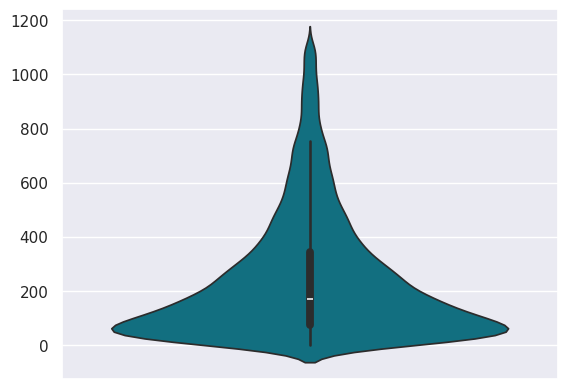

In [53]:
print(f'{duration_series[duration_series > 0].count() / duration_series.shape[0]:.3%} cases with idle time')
sns.violinplot(duration_series[(duration_series > 0) & (duration_series < duration_series.quantile(0.98))])

In [54]:
print(df_excav_processed.columns.tolist())
print(df_contingency.columns.tolist())

['id', 'equipment_id', 'shiftid', 'activity', 'timestamp', 'timestamp_end', 'executor', 'load_location', 'dump_location']
['id', 'fieldid', 'shiftid', 'timestamp', 'duration', 'equipment_id', 'stop_code', 'stop_reason', 'status_id', 'status_name', 'timecat', 'timecatid', 'timestamp_end', 'activity']


In [55]:
def compatibilize_dataframes(df_1: pd.DataFrame, df_2: pd.DataFrame, sort_list: list[str] = []) -> pd.DataFrame:
  df_1_copy = df_1.copy()
  df_2_copy = df_2.copy()
  set_1_cols = set(df_1.columns)
  set_2_cols = set(df_2.columns)

  for missing_col in set_2_cols.difference(set_1_cols):
    df_1_copy[missing_col] = pd.Series(dtype=df_2_copy[missing_col].dtype)

  for missing_col in set_1_cols.difference(set_2_cols):
    df_2_copy[missing_col] = pd.Series(dtype=df_1_copy[missing_col].dtype)
  
  return pd.concat([df_1, df_2]).sort_values(by=[*sort_list, 'timestamp'])

In [90]:
# Here there's also more equipments registered that have a hangtime: "BH12", "CF11", "BH09", "CF10"
# Two options: Remove this from the events in the event log, or extract these activities from Databricks
print(df_excav_processed['equipment_id'].unique())
print(df_contingency['equipment_id'].unique())

['PA03' 'PA11' 'PA05' 'BH09' 'BH12' 'CF11' 'PA04' 'CF10' 'PA10' 'PA07']
['PA04' 'PA05' 'PA07' 'CF11' 'PA03' 'PA11' 'CF10' 'BH12' 'BH09' 'PA10']


In [57]:
df_join = compatibilize_dataframes(df_excav_processed, df_contingency).reset_index(drop=True)
total_rows = df_join.shape[0]
# items_to_remove_by_equipment_id = ['BH12', 'CF11', 'BG09', 'CF10']
# df_join = df_join[~df_join['equipment_id'].isin(items_to_remove_by_equipment_id)]
print(f'Filtered {total_rows - df_join.shape[0]} rows. Total of {df_join.shape[0]} rows')

Filtered 0 rows. Total of 52273 rows


In [58]:
df_join[df_join['activity'] != 'En espera'].head()

,id,equipment_id,shiftid,activity,timestamp,timestamp_end,executor,load_location,dump_location,fieldid,duration,stop_code,stop_reason,status_id,status_name,timecat,timecatid
2,2402250020010014808,PA05,240225002,Traslado,2024-02-25 12:37:37,2024-02-25 12:53:11,NaN,NaN,NaN,03:37:37,934.0,212.0,Traslado,226.0,Demora,Demora Nprog,231.0
14,2402250020010743940,PA05,240225002,En Rampa,2024-02-25 12:53:11,2024-02-25 14:03:42,NaN,NaN,NaN,03:53:11,4231.0,109.0,En Rampa,224.0,Efectivo,Efectivo,229.0
40,2402250020011303760,PA10,240225002,Reparacion de piso,2024-02-25 13:07:50,2024-02-25 13:22:24,NaN,NaN,NaN,04:07:50,874.0,216.0,Reparacion de piso,226.0,Demora,Demora Nprog,231.0
55,2402250020012209624,BH09,240225002,Limpieza frente de carguio,2024-02-25 13:22:09,2024-02-25 13:28:20,NaN,NaN,NaN,04:22:09,371.0,214.0,Limpieza frente de carguio,226.0,Demora,Demora Nprog,231.0
56,2402250020012209876,PA10,240225002,Por ambos lados,2024-02-25 13:22:24,2024-02-25 13:48:46,NaN,NaN,NaN,04:22:24,1582.0,102.0,Por ambos lados,224.0,Efectivo,Efectivo,229.0


In [59]:
df_cont_eda = df_excav_processed.copy()
df_cont_eda['equipment_type'] = df_cont_eda['equipment_id'].str[0:2]
df_cont_eda.head()

,id,equipment_id,shiftid,activity,timestamp,timestamp_end,executor,load_location,dump_location,equipment_type
0,0,PA03,240326001,En espera,2024-03-26 08:07:39,2024-03-26 08:08:10,CLAUDIO OLIVARES SILVA,Disparo,Botadero,PA
1,1,PA11,240326001,En espera,2024-03-26 08:13:48,2024-03-26 08:13:48,VICTOR ROJAS TAPIA,Disparo,Botadero,PA
2,2,PA05,240326001,En espera,2024-03-26 08:20:43,2024-03-26 08:26:02,JORGE VEGA CEBRA,Disparo,Stock,PA
3,3,PA11,240326001,En espera,2024-03-26 08:13:20,2024-03-26 08:13:20,VICTOR ROJAS TAPIA,Disparo,Botadero,PA
4,4,BH09,240326001,En espera,2024-03-26 08:24:58,2024-03-26 08:26:29,HECTOR BLANCO VALDIVIA,Disparo,Stock,BH


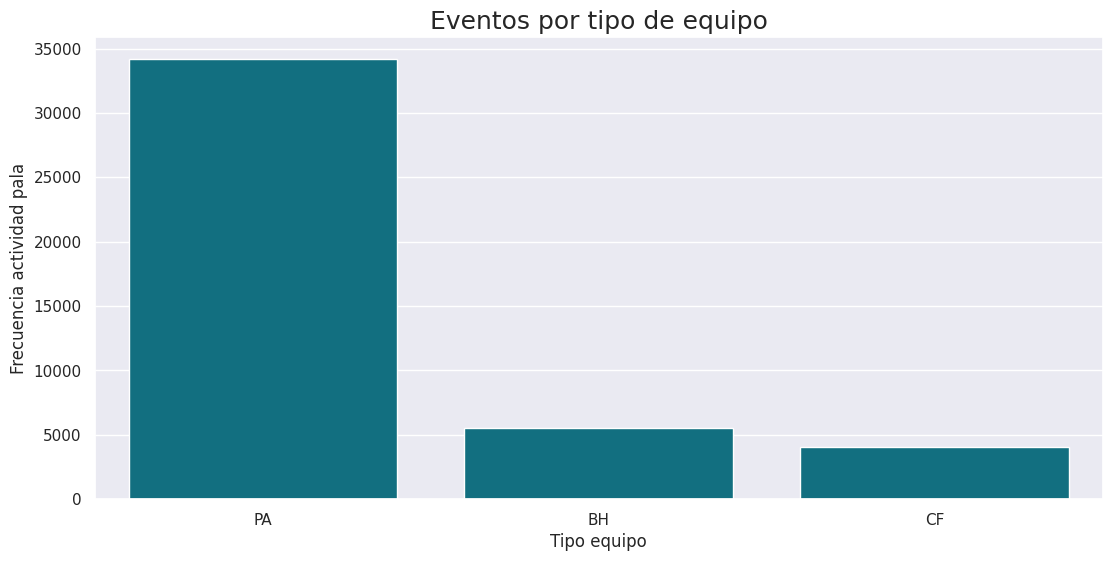

In [60]:
fig, ax = plt.subplots(figsize=(13, 6))
ax = sns.countplot(df_cont_eda, x='equipment_type')
ax.set(xlabel='Tipo equipo', ylabel='Frecuencia actividad pala');
plt.title("Eventos por tipo de equipo", fontsize=18)
plt.savefig('images/shovel/count.png', dpi=fig.dpi)
# fig.show()

In [61]:
print(f"First time {df_cont_eda['timestamp'].min()}")
print(f"Last time {df_cont_eda['timestamp_end'].max()}")

First time 2024-02-25 12:33:37
Last time 2024-03-26 08:31:02


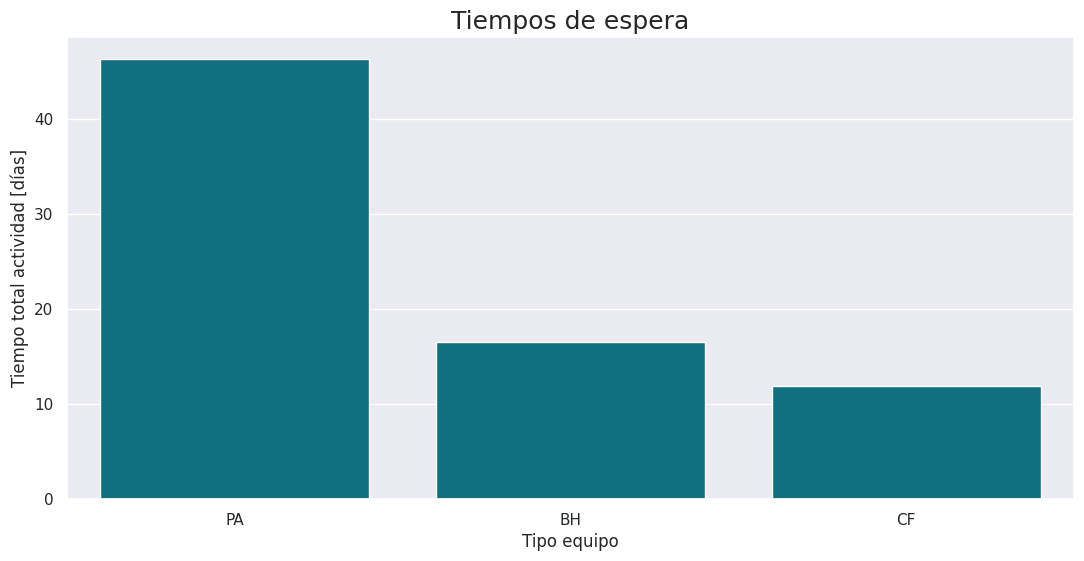

In [62]:
df_cont_eda['duration'] = (df_cont_eda['timestamp_end'] - df_cont_eda['timestamp']).dt.total_seconds() / (60 * 60 * 24)
df_aggregate_time = df_cont_eda.groupby(by='equipment_type')['duration'].sum().reset_index()
df_order = pd.DataFrame(data=[['PA', 1], ['BH', 2], ['CF', 3]], columns=['equipment_type', 'order'])
df_aggregate_time = df_aggregate_time.merge(df_order, on='equipment_type').sort_values(by='order')
fig, ax = plt.subplots(figsize=(13, 6))
ax = sns.barplot(df_aggregate_time, x='equipment_type', y='duration')
ax.set(xlabel='Tipo equipo', ylabel='Tiempo total actividad [días]');
plt.title('Tiempos de espera', fontsize=18)
plt.savefig('images/shovel/count.png', dpi=fig.dpi)

Text(0.5, 1.0, 'Eventos por carga')

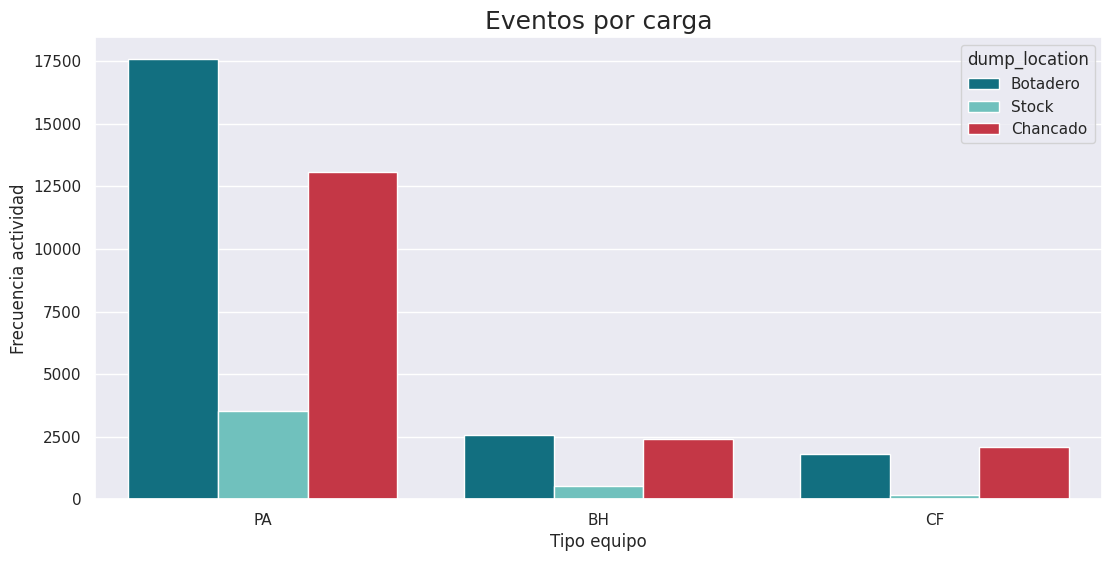

In [63]:
fig, ax = plt.subplots(figsize=(13, 6))
df_cont_eda_filtered = df_cont_eda[df_cont_eda['dump_location'] != 'Disparo']
ax = sns.countplot(df_cont_eda_filtered, x='equipment_type', hue='dump_location')
ax.set(xlabel='Tipo equipo', ylabel='Frecuencia actividad');
plt.title('Eventos por carga', fontsize=18)

In [64]:
df_cont_eda['duration_hours'] = df_cont_eda['duration'] * 24
total_time_lost = df_cont_eda.sort_values(by='duration', ascending=False)['duration'].sum()
print(f'Total tiempo perdido {total_time_lost:.1f} días')

Total tiempo perdido 74.7 días


In [65]:
from event_log_integrity import events_contained_metric, overlap_metric

In [66]:
df_join.head()

,id,equipment_id,shiftid,activity,timestamp,timestamp_end,executor,load_location,dump_location,fieldid,duration,stop_code,stop_reason,status_id,status_name,timecat,timecatid
0,43862,PA07,240225002,En espera,2024-02-25 12:33:37,2024-02-25 12:33:37,PATRICIO PIZARRO CORTES,Disparo,Chancado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,43871,PA11,240225002,En espera,2024-02-25 12:36:22,2024-02-25 12:48:30,ROBERTO CASTILLO OLIVARES,Disparo,Botadero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2402250020010014808,PA05,240225002,Traslado,2024-02-25 12:37:37,2024-02-25 12:53:11,NaN,NaN,NaN,03:37:37,934.0,212.0,Traslado,226.0,Demora,Demora Nprog,231.0
3,43866,BH12,240225002,En espera,2024-02-25 12:38:22,2024-02-25 12:46:36,RODRIGO PIZARRO MAUREIRA,Disparo,Botadero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,43873,PA10,240225002,En espera,2024-02-25 12:39:58,2024-02-25 12:39:58,RIGOBERTO OLIVARES HERRERA,Disparo,Stock,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [67]:
df_not_efective = df_join[df_join['status_name'] != 'Efectivo']
events_contained_metric(df_not_efective[df_not_efective['activity'] != 'En espera'].sort_values(by=['equipment_id', 'timestamp']).rename(columns={'id': 'index'}));
events_contained_metric(df_not_efective[df_not_efective['activity'] == 'En espera'].sort_values(by=['equipment_id', 'timestamp']).rename(columns={'id': 'index'}));
overlap_metric(df_not_efective[df_not_efective['activity'] != 'En espera'].sort_values(by=['equipment_id', 'timestamp']).rename(columns={'id': 'index'}));
overlap_metric(df_not_efective[df_not_efective['activity'] == 'En espera'].sort_values(by=['equipment_id', 'timestamp']).rename(columns={'id': 'index'}));
events_contained_metric(df_not_efective.sort_values(by=['equipment_id', 'timestamp']).rename(columns={'id': 'index'}))
overlap_metric(df_not_efective.sort_values(by=['equipment_id', 'timestamp']).rename(columns={'id': 'index'}))

Entirely contained events: 0.00%
Entirely contained events: 16.96%
Overlap Metric: 0.00%
Overlap Metric: 2.63%
Entirely contained events: 16.83%
Overlap Metric: 3.74%


,activity,future_activity
3,En espera,Limpieza frente de carguio
11,En espera,En espera
13,En espera,Carga de combustible
29,Limpieza frente de carguio,En espera
46,Limpieza frente de carguio,En espera
...,...,...
48657,Limpieza frente de carguio,En espera
48679,Traslado,En espera
48710,En espera,Limpieza frente de carguio
48754,En espera,Limpieza frente de carguio


In [68]:
events_contained_metric(df_not_efective.sort_values(by=['equipment_id', 'timestamp']).rename(columns={'id': 'index'}));
overlap_metric(df_not_efective.sort_values(by=['equipment_id', 'timestamp']).rename(columns={'id': 'index'}));
events_contained_metric(df_not_efective[df_not_efective['activity'] != 'En espera'].\
                            sort_values(by=['equipment_id', 'timestamp']).\
                            rename(columns={'id': 'index'}));

Entirely contained events: 16.83%
Overlap Metric: 3.74%
Entirely contained events: 0.00%


In [69]:
df_join[df_join['activity'] != 'En espera'].head()

,id,equipment_id,shiftid,activity,timestamp,timestamp_end,executor,load_location,dump_location,fieldid,duration,stop_code,stop_reason,status_id,status_name,timecat,timecatid
2,2402250020010014808,PA05,240225002,Traslado,2024-02-25 12:37:37,2024-02-25 12:53:11,NaN,NaN,NaN,03:37:37,934.0,212.0,Traslado,226.0,Demora,Demora Nprog,231.0
14,2402250020010743940,PA05,240225002,En Rampa,2024-02-25 12:53:11,2024-02-25 14:03:42,NaN,NaN,NaN,03:53:11,4231.0,109.0,En Rampa,224.0,Efectivo,Efectivo,229.0
40,2402250020011303760,PA10,240225002,Reparacion de piso,2024-02-25 13:07:50,2024-02-25 13:22:24,NaN,NaN,NaN,04:07:50,874.0,216.0,Reparacion de piso,226.0,Demora,Demora Nprog,231.0
55,2402250020012209624,BH09,240225002,Limpieza frente de carguio,2024-02-25 13:22:09,2024-02-25 13:28:20,NaN,NaN,NaN,04:22:09,371.0,214.0,Limpieza frente de carguio,226.0,Demora,Demora Nprog,231.0
56,2402250020012209876,PA10,240225002,Por ambos lados,2024-02-25 13:22:24,2024-02-25 13:48:46,NaN,NaN,NaN,04:22:24,1582.0,102.0,Por ambos lados,224.0,Efectivo,Efectivo,229.0


In [70]:
from plot_utils import plot_pareto

In [71]:
df_pareto = df_contingency[df_contingency['status_name'] != 'Efectivo'].groupby(by='activity')['duration'].\
              sum().reset_index().sort_values(by='duration', ascending=False)

df_pareto['duration'] = df_pareto['duration'] / (60 * 60 * 24)
fig = plot_pareto(df_pareto, 'activity', 'duration', title='Pareto para contingencias de la pala', ylabel='Tiempo total [días]')
fig.show()
SAVE_PATH = 'images/shovel/global_pareto.png'
SAVE_SPECS = {'width': 1500, 'height': 700, 'scale': 1}
fig.write_image(SAVE_PATH, **SAVE_SPECS)

In [109]:
# equipment_code can be: 'CF', 'BH' or 'PA'
equipment_code = 'CF'
df_pareto_pa = df_contingency[df_contingency['status_name'] != 'Efectivo'][df_contingency['equipment_id'].str.startswith(equipment_code)].\
              groupby(by='activity')['duration'].\
              sum().reset_index().sort_values(by='duration', ascending=False)
df_pareto_pa['duration'] = df_pareto_pa['duration'] / (60 * 60 * 24)
fig = plot_pareto(df_pareto_pa, 'activity', 'duration', title=f'Pareto para contingencias de la pala ({equipment_code})', ylabel='Tiempo total [días]')
fig.show()

/tmp/ipykernel_13640/366582023.py:2: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.



In [97]:
df_contingency['activity'].nunique()

58

In [99]:
# Las actividades no son las mismas entre los equipos
all_activities = set(df_contingency['activity'].unique())
pa_activities = set(df_contingency[df_contingency['equipment_id'].str.startswith('PA')]['activity'].unique())
bh_activities = set(df_contingency[df_contingency['equipment_id'].str.startswith('BH')]['activity'].unique())
cf_activities = set(df_contingency[df_contingency['equipment_id'].str.startswith('CF')]['activity'].unique())

In [100]:
print('Actividades faltantes')
print(all_activities - pa_activities)
print(all_activities - bh_activities)
print(all_activities - cf_activities)
print(len(all_activities))
print(len(pa_activities))
print(len(bh_activities))
print(len(cf_activities))

{'Sistema contra incendios', 'Cambio neumatico programado', 'Detenido por somnolencia', 'Carga de combustible', 'CHEQUEO NEUMATICO PROGRAMADO', 'BOTADERO/CHANCADO NO DISPONIB', 'Radio musical', 'CHEQUEO NEUMATICO NO PROGRAMA', 'Mant. No Prog. Neumaticos', 'Mant. Prog. Neumaticos', 'Falla motor diesel', 'SISTEMA CAS', 'Pinchazo o rotura neumaticos'}
{'Sistema contra incendios', 'Corte de energia - operaciona', 'Cambio neumatico programado', 'BOLONES POR AMBOS LADOS', 'Falla electrica imprevista', 'CHEQUEO NEUMATICO PROGRAMADO', 'Cables electricos', 'Mant. Prog. Balde', 'BOTADERO/CHANCADO NO DISPONIB', 'Requerimiento de equipo de ap', 'CHEQUEO NEUMATICO NO PROGRAMA', 'Movimiento de cables', 'Mant. No Prog. Neumaticos', 'Mant. Prog. Neumaticos', 'TRASLADO MANTENCION', 'Pinchazo o rotura neumaticos', 'ESPERA DE PATIO', 'Sin frente de carguio'}
{'Corte de energia - operaciona', 'Detenido por somnolencia', 'Falla electrica imprevista', 'Cables electricos', 'Mant. Prog. Balde', 'Mina en emerg

In [105]:
print("PA: {}".format(pa_activities - bh_activities - cf_activities))
print("BH: {}".format(bh_activities - pa_activities - cf_activities))
print("CF: {}".format(cf_activities - bh_activities - pa_activities))

PA: {'Corte de energia - operaciona', 'Falla electrica imprevista', 'Cables electricos', 'Mant. Prog. Balde', 'Requerimiento de equipo de ap', 'Movimiento de cables', 'ESPERA DE PATIO'}
BH: {'Falla motor diesel', 'SISTEMA CAS', 'Detenido por somnolencia', 'Radio musical'}
DF: {'Sistema contra incendios', 'Cambio neumatico programado', 'CHEQUEO NEUMATICO PROGRAMADO', 'BOTADERO/CHANCADO NO DISPONIB', 'CHEQUEO NEUMATICO NO PROGRAMA', 'Mant. No Prog. Neumaticos', 'Mant. Prog. Neumaticos', 'Pinchazo o rotura neumaticos'}
